--------------
# Dataset:
---------------
The dataset we are going to use in this exercise is from a hypothetical project with the primary objective of providing assistance to individuals living with HIV (PLHIV) in attaining viral load suppression. To achieve this goal, a series of  activities, including home visits conducted by Community Health Workers (CHWs) and enrollment into support groups, were implimented. The aim of this analysis is to ascertain whether these activities, alongside treatment adherence, gender, age, and duration under treatment and care, have an impact on the viral load suppression of PLHIV. Furthermore, we would like to develop a predictive model or equation for the estimating the level of viral load in PLHIV. Linear regression was employed as the analytical technique to address these inquiries.

# Libraries:

In [1]:
# Loading the libraries

import pandas as pd # import pandas library as pd
import numpy as np # import numpy library as np

import matplotlib.pyplot as plt
import seaborn as sns

import scipy.stats as stats
import statsmodels.api as sm

# Exploration of the data:

In [2]:
# loading our dataset

data = pd.read_csv("HIV patients follow_up.csv")

In [3]:
# Viewing the first 5 rows

data.head()

,gender,Age,Community Unit,Level of education,Years under care and treatment,Supported by CHWs,Part of a support group,Adherence,Viral load
0,male,31,community A,no formal education,15,yes,yes,0.92,305
1,female,31,community A,primary,13,yes,no,0.97,305
2,male,32,community A,college,15,yes,yes,0.98,311
3,male,30,community A,college,13,no,no,0.93,312
4,male,32,community A,primary,15,yes,yes,0.97,320


In [4]:
# Computing the summary statistics

data.describe()

,Age,Years under care and treatment,Adherence,Viral load
count,100.000000,100.000000,100.000000,100.000000
mean,25.990000,7.530000,0.567000,396.550000
std,5.560494,3.661029,0.219635,46.224174
min,12.000000,1.000000,0.130000,305.000000
25%,22.000000,4.000000,0.390000,364.750000
50%,26.000000,8.000000,0.610000,395.000000
75%,28.000000,10.000000,0.722500,426.500000
max,44.000000,15.000000,0.980000,536.000000


In [5]:
# Descriptive statistics of key variables by gender

grouped_data = data.groupby('gender').agg({'Viral load': 'mean', 'Years under care and treatment': 'mean', 'Adherence': 'mean', 'Age': 'mean'})
grouped_data

,Viral load,Years under care and treatment,Adherence,Age
gender,,,,
female,398.033898,7.338983,0.556102,26.288136
male,394.414634,7.804878,0.582683,25.560976


# Assumptions Testing:

#### Linearity of variables

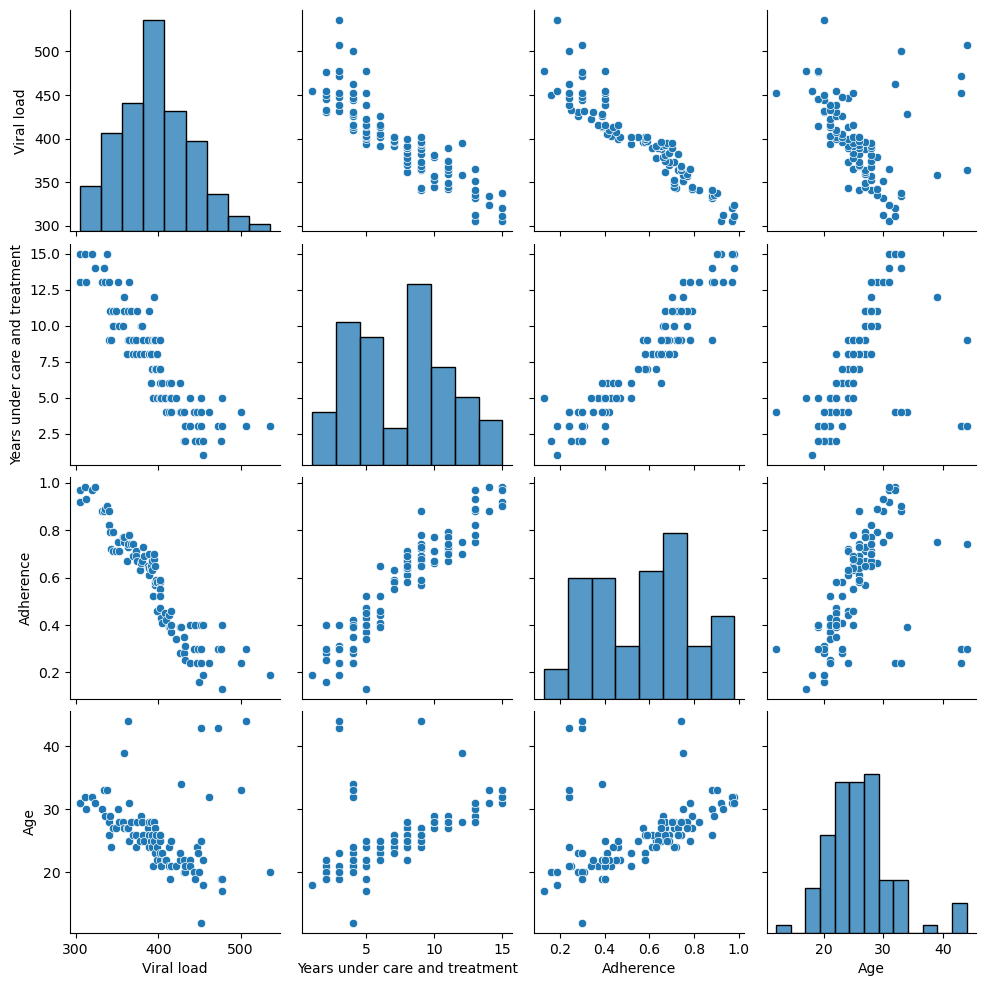

In [6]:
# Pair plots of 'Viral load', 'Years under care and treatment', 'Adherence' and 'Age'

sns.pairplot(data[['Viral load', 'Years under care and treatment', 'Adherence','Age']])

#### Normality of the dependent variable

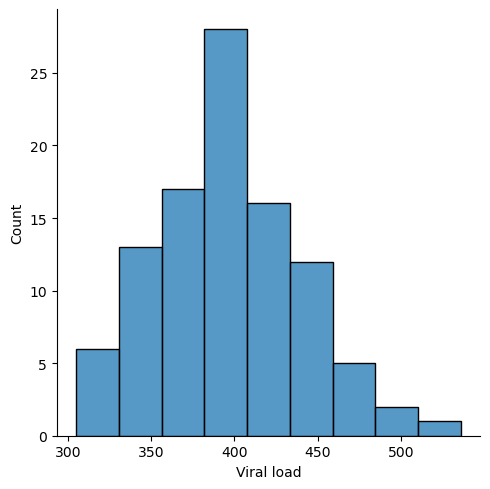

In [7]:
sns.displot(data["Viral load"])

In [8]:
# Testing of normality using the shapiro wilk test

from scipy.stats import shapiro
shapiro(data['Viral load'])

ShapiroResult(statistic=0.9869128465652466, pvalue=0.43179038166999817)

##### Creating some additional independent variables to be included in the correlation analysis and regression model

In [9]:
# Creating a binary integer variable for gender, 1 represent a female and 0 represent male

data["female_patient"] = np.select([data["gender"] == "female",data["gender"] == "male"], [1, 0])

In [10]:
# Creating an ordinal variable for education: 0=No formal education, 1=primary,3=secondary,4=high school,5=college

data["Education"]=np.select([data["Level of education"]=="no formal education",data["Level of education"]=="primary",data["Level of education"]=="secondary",data["Level of education"]=="high school",data["Level of education"]=="college"],[0,1,2,3,4])

In [11]:
# Creating a binary integer variable for CHW support, 1=PLHIV supported with a CHW and 0=PLHIV not supported by a CHW

data["CHW support"]=np.select([data["Supported by CHWs"] == "yes",data["Supported by CHWs"] == "no"], [1, 0])

In [12]:
# Creating a binary integer variable for enrolment in a support group, where 1=PLHIV enrolled in a support group 0=PLHIV not enroled in a support group

data["Support group"]=np.select([data["Part of a support group"] == "yes",data["Part of a support group"] == "no"], [1, 0])

In [13]:
# Extracting the numeric variables from the dataset

integer_columns = data.select_dtypes(include='integer')

# Correlation analysis:

In [14]:
# Creating a correlation matrix with coefficients and p-values

def correlation_matrix(integer_columns):
    # Calculate correlation coefficients
    correlation_matrix = integer_columns.corr()

    # Calculate p-values for correlation coefficients
    p_values = pd.DataFrame(np.zeros_like(correlation_matrix.values), columns=correlation_matrix.columns, index=correlation_matrix.index)

    for i in range(len(integer_columns.columns)):
        for j in range(i+1, len(integer_columns.columns)):
            x = integer_columns.iloc[:, i]
            y = integer_columns.iloc[:, j]
            _, p_value = stats.pearsonr(x, y)
            p_values.iloc[i, j] = p_value
            p_values.iloc[j, i] = p_value

    # Create a DataFrame to display correlation coefficients and p-values
    corr_with_p_values = correlation_matrix.copy()
    for i in range(len(correlation_matrix.columns)):
        for j in range(len(correlation_matrix.columns)):
            coeff = correlation_matrix.iloc[i, j]
            p_value = p_values.iloc[i, j]
            if p_value < 0.05:
                corr_with_p_values.iloc[i, j] = f"**{coeff:.2f} (p-value: {p_value:.3f})"
            else:
                corr_with_p_values.iloc[i, j] = f"{coeff:.2f} (p-value: {p_value:.3f})"

    # Display correlation matrix with coefficients and p-values as one table
    return corr_with_p_values.style.set_caption("Correlation Matrix with Coefficients and p-values").\
        applymap(lambda x: 'font-weight: bold' if '**' in x else '')

In [15]:
correlation_matrix(integer_columns)

,Age,Years under care and treatment,Viral load,female_patient,Education,CHW support,Support group
Age,**1.00 (p-value: 0.000),**0.46 (p-value: 0.000),**-0.31 (p-value: 0.002),0.06 (p-value: 0.523),-0.04 (p-value: 0.702),-0.02 (p-value: 0.870),0.13 (p-value: 0.204)
Years under care and treatment,**0.46 (p-value: 0.000),**1.00 (p-value: 0.000),**-0.88 (p-value: 0.000),-0.06 (p-value: 0.534),-0.05 (p-value: 0.624),-0.01 (p-value: 0.910),**0.37 (p-value: 0.000)
Viral load,**-0.31 (p-value: 0.002),**-0.88 (p-value: 0.000),**1.00 (p-value: 0.000),0.04 (p-value: 0.702),0.19 (p-value: 0.059),-0.03 (p-value: 0.795),**-0.30 (p-value: 0.003)
female_patient,0.06 (p-value: 0.523),-0.06 (p-value: 0.534),0.04 (p-value: 0.702),**1.00 (p-value: 0.000),-0.07 (p-value: 0.519),0.05 (p-value: 0.653),-0.06 (p-value: 0.585)
Education,-0.04 (p-value: 0.702),-0.05 (p-value: 0.624),0.19 (p-value: 0.059),-0.07 (p-value: 0.519),**1.00 (p-value: 0.000),0.02 (p-value: 0.831),0.08 (p-value: 0.437)
CHW support,-0.02 (p-value: 0.870),-0.01 (p-value: 0.910),-0.03 (p-value: 0.795),0.05 (p-value: 0.653),0.02 (p-value: 0.831),**1.00 (p-value: 0.000),-0.14 (p-value: 0.164)
Support group,0.13 (p-value: 0.204),**0.37 (p-value: 0.000),**-0.30 (p-value: 0.003),-0.06 (p-value: 0.585),0.08 (p-value: 0.437),-0.14 (p-value: 0.164),**1.00 (p-value: 0.000)


# The Regression Model:

###### Defining variables to be included in the model

In [16]:
# The dependent variable
y=data[['Viral load']]

In [17]:
# The independent variables
X=data[['female_patient','Education', 'CHW support', 'Support group','Age','Years under care and treatment','Adherence']]

In [18]:
# Calculation of the regression model

X2 = sm.add_constant(X) # adds a constant term to the feature matrix X using the add_constant()
est = sm.OLS(y, X2) #creates an Ordinary Least Squares (OLS) regression model using the OLS()
est2 = est.fit() #fits the OLS model to the data using the fit() method. It estimates the coefficients of the regression model using the least squares method.
print(est2.summary()) #prints the summary of the regression results. 

                            OLS Regression Results                            
Dep. Variable:             Viral load   R-squared:                       0.887
Model:                            OLS   Adj. R-squared:                  0.878
Method:                 Least Squares   F-statistic:                     102.7
Date:                Sat, 08 Jul 2023   Prob (F-statistic):           1.17e-40
Time:                        10:10:18   Log-Likelihood:                -415.92
No. Observations:                 100   AIC:                             847.8
Df Residuals:                      92   BIC:                             868.7
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

##### Prediction

# Conclusion and recommendations: